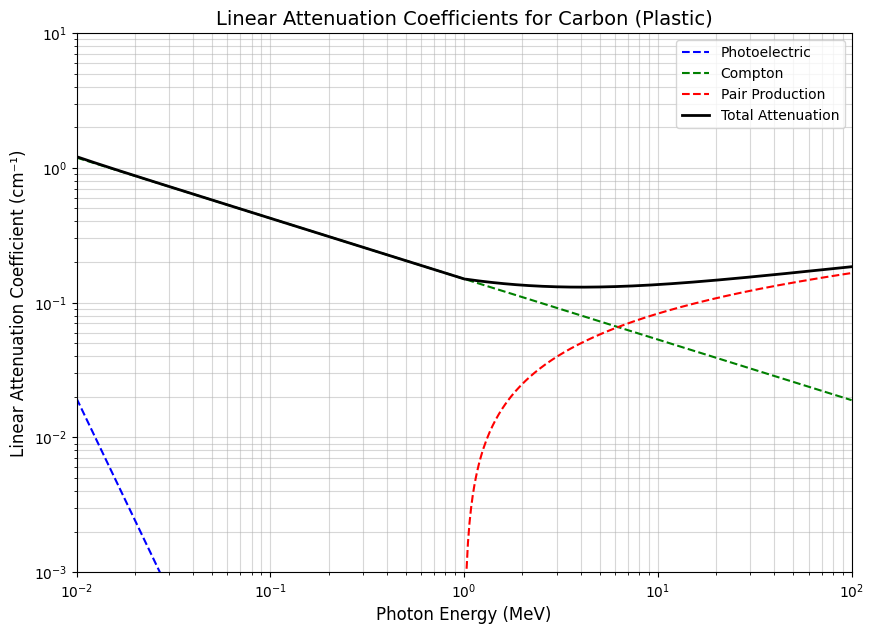

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Energy range from 0.01 MeV to 100 MeV
energies = np.logspace(-2, 2, 500)

# Physical Constants/Scaling for Carbon (Z=6, density ~2.26 g/cm3 for graphite)
# Note: For plastic, density would be ~1.0, but we'll use Z=6 characteristics.
rho = 1.0  # Normalized to 1 g/cm3 for typical plastic

# 1. Photoelectric Effect (Approx: scales with Z^4 / E^3)
# Dominant at very low energies
mu_pe = 0.015 * (6**4 / (energies * 1000)**3) * rho

# 2. Compton Scattering (Klein-Nishina approximation simplified)
# Dominant for Carbon from ~20keV to ~20MeV
mu_compton = 0.15 * (energies**-0.45) * rho

# 3. Pair Production (Threshold at 1.022 MeV)
mu_pair = np.where(energies > 1.022, 0.001 * (6**2) * np.log(energies), 0)

# Total Attenuation
mu_total = mu_pe + mu_compton + mu_pair

# Plotting
plt.figure(figsize=(10, 7))
plt.loglog(energies, mu_pe, '--', label='Photoelectric', color='blue')

plt.loglog(energies, mu_compton, '--', label='Compton', color='green')
plt.loglog(energies, mu_pair, '--', label='Pair Production', color='red')
plt.loglog(energies, mu_total, '-', label='Total Attenuation', color='black', linewidth=2)

plt.title('Linear Attenuation Coefficients for Carbon (Plastic)', fontsize=14)
plt.xlabel('Photon Energy (MeV)', fontsize=12)
plt.ylabel('Linear Attenuation Coefficient (cm⁻¹)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.ylim(0.001, 10)
plt.xlim(0.01, 100)

plt.show()